In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
import re
import os

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = "viridis"
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

def savefig(fig, name, dpi=300):
    fig.savefig(os.path.join(FIGDIR, name), dpi=dpi, bbox_inches="tight")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [16]:
import kagglehub
import pandas as pd
import os

def download_and_load_data():
    """
    Downloads the Medical Transcriptions dataset from Kaggle using kagglehub
    and loads the main CSV file into a Pandas DataFrame.

    Returns:
        pd.DataFrame: Raw dataset containing medical transcriptions.
    """
    # Download the latest version of the dataset
    # it won't re-download if the files exist, kagglehub handles caching
    path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")

    # Construct the full path to the CSV file
    csv_path = os.path.join(path, "mtsamples.csv")
    df = pd.read_csv(csv_path)

    # remove the redundant index column, usually the case with kaggle datasets
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    return df


df_raw = download_and_load_data()

print("Димензије оригиналног скупа:", df_raw.shape)
print("\nКолоне:", list(df_raw.columns))
print("\nНедостајуће вредности по колони:")
print(df_raw.isna().sum())
print("\nБрој јединствених (неочишћених) вредности medical_specialty:", df_raw["medical_specialty"].nunique())
df_raw.head(3)

C:\Users\HP\DataspellProjects\Inteligentni_sistemi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Димензије оригиналног скупа: (4999, 5)

Колоне: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Недостајуће вредности по колони:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Број јединствених (неочишћених) вредности medical_specialty: 40


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [17]:
def clean_medical_data(df):
    df = df.dropna(subset=["transcription"])
    df["medical_specialty"] = df["medical_specialty"].str.strip()
    counts = df["medical_specialty"].value_counts()
    valid_categories = counts[counts >= 20].index
    df = df[df["medical_specialty"].isin(valid_categories)]
    df = df.reset_index(drop=True)
    return df

df = clean_medical_data(df_raw.copy())

print(f"Пре чишћења: {df_raw.shape[0]} узорака, {df_raw['medical_specialty'].str.strip().nunique()} специјалности")
print(f"После чишћења: {df.shape[0]} узорака, {df['medical_specialty'].nunique()} специјалности")
print(f"Уклоњено: {df_raw.shape[0] - df.shape[0]} узорака ({(df_raw.shape[0]-df.shape[0])/df_raw.shape[0]*100:.1f}%)")

Пре чишћења: 4999 узорака, 40 специјалности
После чишћења: 4841 узорака, 29 специјалности
Уклоњено: 158 узорака (3.2%)


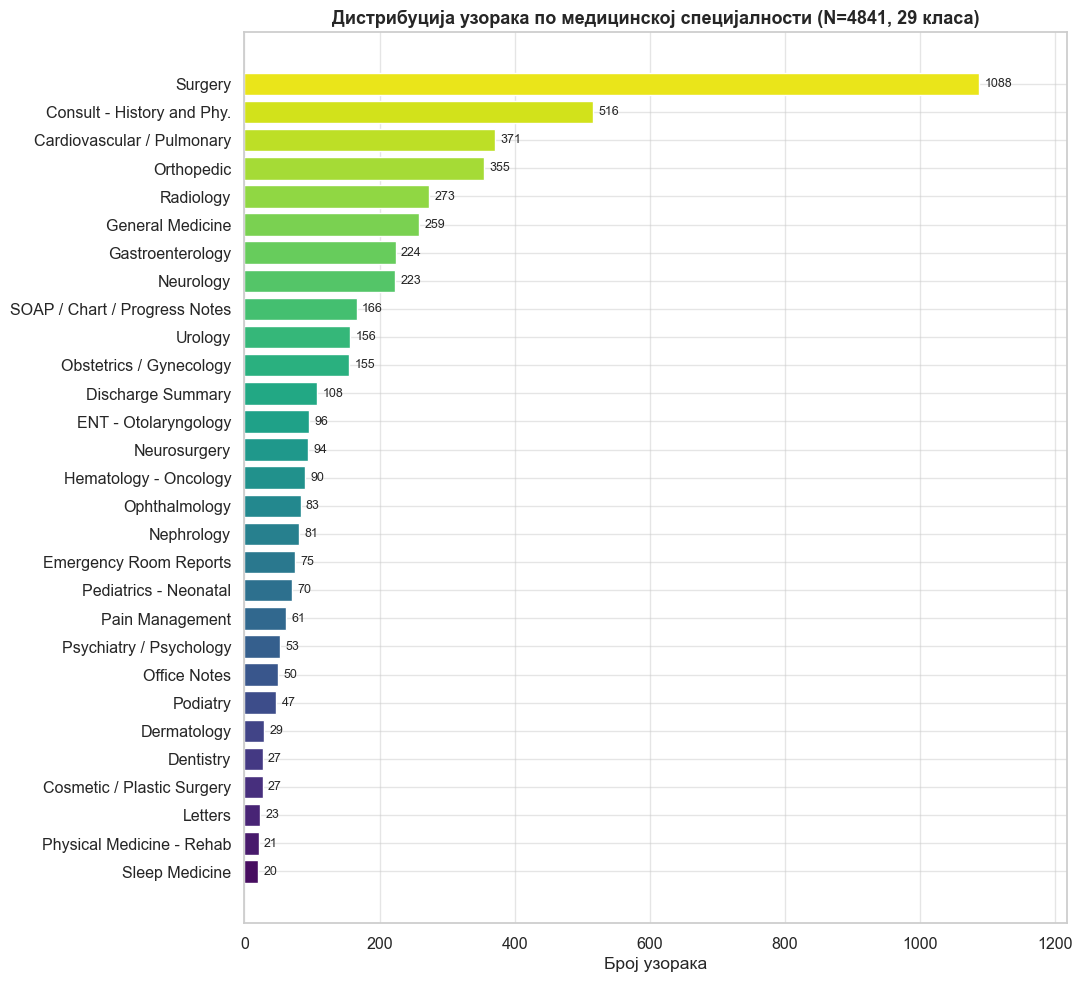

Најзаступљенија класа (Surgery): 1088 узорака (22.5% целог скупа)
Најмање заступљена класа: 20 узорака
Однос највеће према најмањој класи: 54.4 : 1


In [18]:
specialty_counts = df["medical_specialty"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 10))
colors = sns.color_palette(PALETTE, len(specialty_counts))
bars = ax.barh(specialty_counts.index, specialty_counts.values, color=colors)

for bar, val in zip(bars, specialty_counts.values):
    ax.text(val + 8, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=9)

ax.set_xlabel("Број узорака")
ax.set_title("Дистрибуција узорака по медицинској специјалности (N=4841, 29 класа)", fontsize=13, fontweight="bold")
ax.set_xlim(0, specialty_counts.max() * 1.12)
plt.tight_layout()
savefig(fig, "01_distribucija_klasa.png")
plt.show()

print(f"Најзаступљенија класа (Surgery): {specialty_counts.max()} узорака ({specialty_counts.max()/len(df)*100:.1f}% целог скупа)")
print(f"Најмање заступљена класа: {specialty_counts.min()} узорака")
print(f"Однос највеће према најмањој класи: {specialty_counts.max()/specialty_counts.min():.1f} : 1")

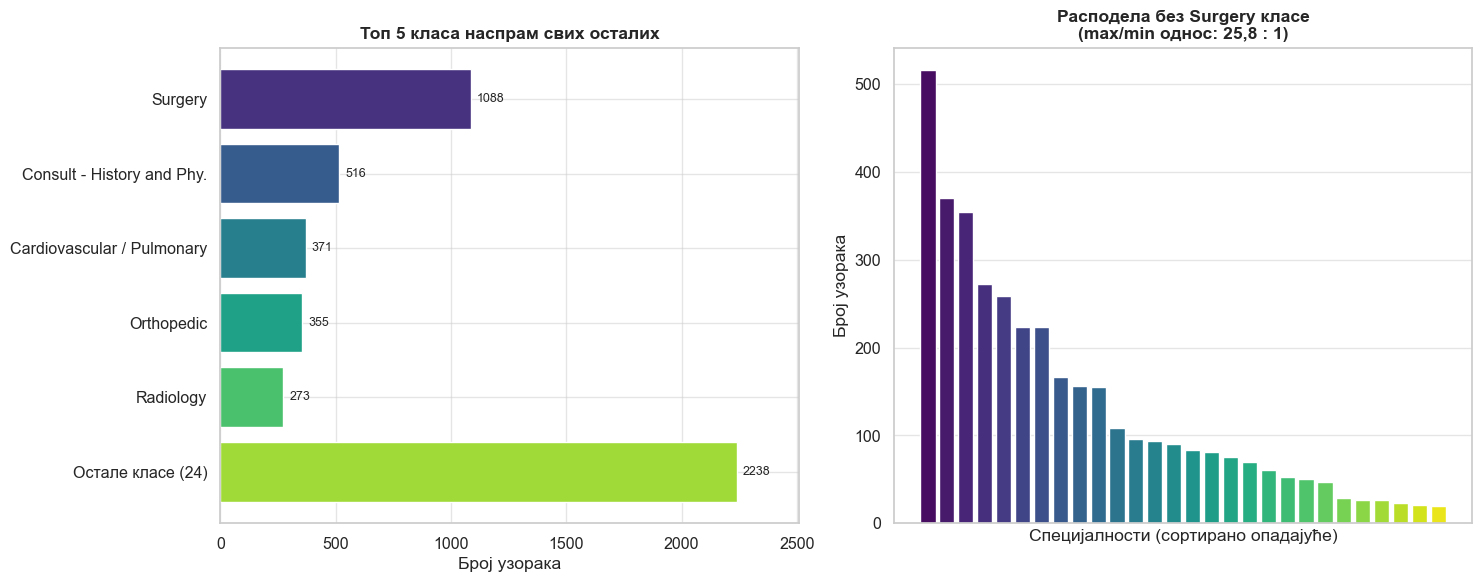

In [19]:
top10 = specialty_counts.sort_values(ascending=False).head(10)
rest_count = specialty_counts.sort_values(ascending=False).iloc[10:].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

labels = list(top10.index[:5]) + ["Остале класе (24)"]
values = list(top10.values[:5]) + [len(df) - top10.values[:5].sum()]
colors2 = sns.color_palette(PALETTE, len(labels))

labels_plot = labels[::-1]
values_plot = values[::-1]
colors_plot = colors2[::-1]

axes[0].barh(labels_plot, values_plot, color=colors_plot)
axes[0].set_xlabel("Број узорака")
axes[0].set_title("Топ 5 класа наспрам свих осталих", fontweight="bold")
for i, v in enumerate(values_plot):
    axes[0].text(v + 25, i, str(v), va="center", fontsize=9)
axes[0].set_xlim(0, max(values_plot) * 1.12)

without_surgery = specialty_counts.drop("Surgery").sort_values(ascending=False)
axes[1].bar(range(len(without_surgery)), without_surgery.values, color=sns.color_palette(PALETTE, len(without_surgery)))
axes[1].set_xticks([])
axes[1].set_xlabel("Специјалности (сортирано опадајуће)", loc="center")
axes[1].set_ylabel("Број узорака")
ratio_str = f"{without_surgery.max() / without_surgery.min():.1f}".replace(".", ",")
axes[1].set_title(f"Расподела без Surgery класе\n(max/min однос: {ratio_str} : 1)", fontweight="bold")

plt.tight_layout()
savefig(fig, "02_surgery_efekat.png")
plt.show()

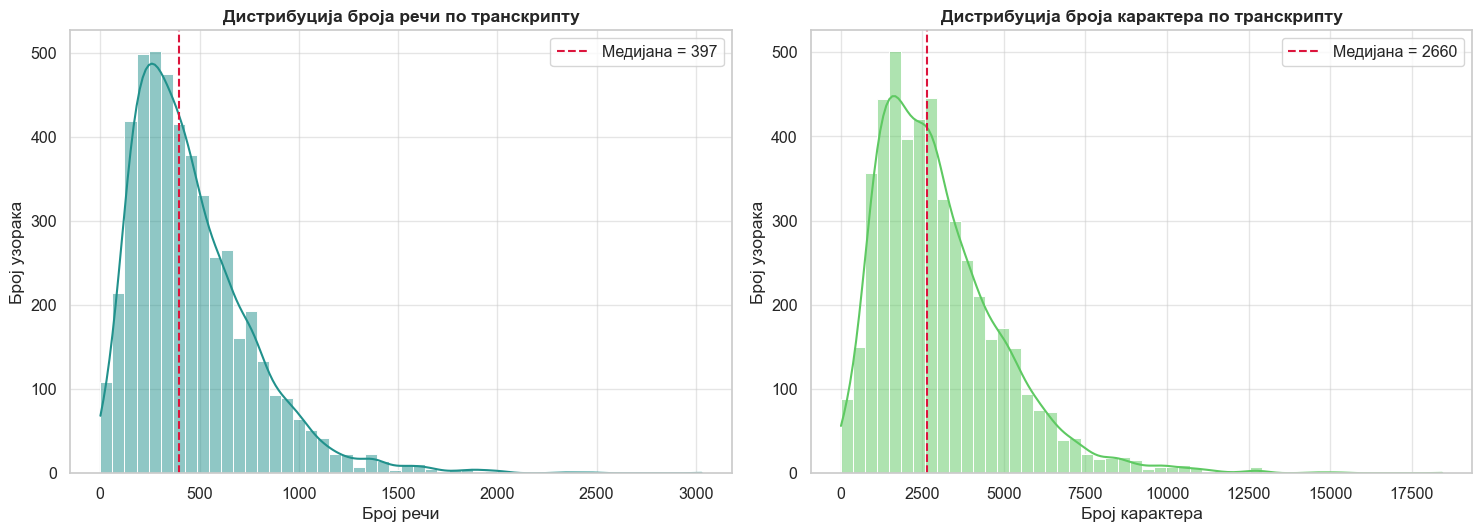

       word_count  char_count
count      4841.0      4841.0
mean        460.8      3025.1
std         307.8      1943.9
min           1.0        11.0
25%         241.0      1607.0
50%         397.0      2660.0
75%         612.0      3982.0
max        3029.0     18425.0


In [20]:
df["word_count"] = df["transcription"].str.split().str.len()
df["char_count"] = df["transcription"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.histplot(df["word_count"], bins=50, kde=True, ax=axes[0], color=sns.color_palette(PALETTE, 3)[1])
axes[0].set_title("Дистрибуција броја речи по транскрипту", fontweight="bold")
axes[0].set_xlabel("Број речи")
axes[0].set_ylabel("Број узорака")
axes[0].axvline(df["word_count"].median(), color="crimson", linestyle="--", label=f'Медијана = {df["word_count"].median():.0f}')
axes[0].legend()

sns.histplot(df["char_count"], bins=50, kde=True, ax=axes[1], color=sns.color_palette(PALETTE, 3)[2])
axes[1].set_title("Дистрибуција броја карактера по транскрипту", fontweight="bold")
axes[1].set_xlabel("Број карактера")
axes[1].set_ylabel("Број узорака")
axes[1].axvline(df["char_count"].median(), color="crimson", linestyle="--", label=f'Медијана = {df["char_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
savefig(fig, "03_duzina_distribucija.png")
plt.show()

print(df[["word_count", "char_count"]].describe().round(1))

C:\Users\HP\AppData\Local\Temp\ipykernel_13460\3890027799.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top12, y="medical_specialty", x="word_count", order=order, palette=PALETTE, ax=ax)


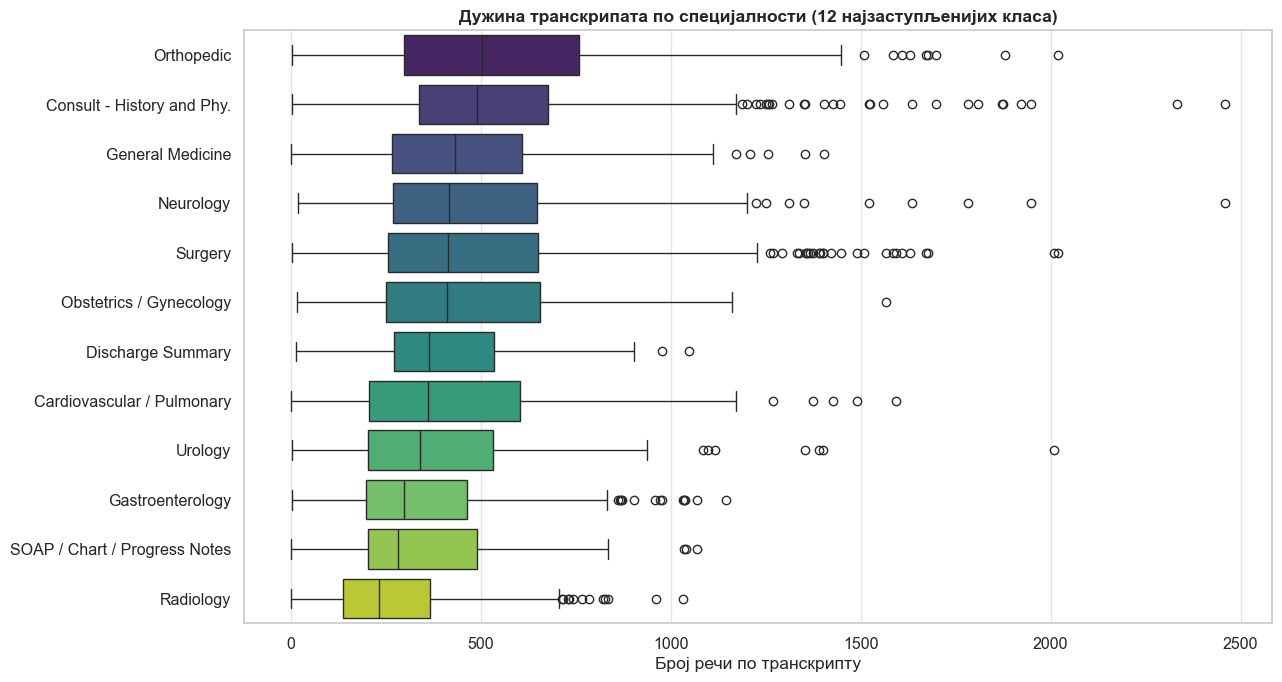

In [21]:
top12 = specialty_counts.sort_values(ascending=False).head(12).index
df_top12 = df[df["medical_specialty"].isin(top12)]

order = df_top12.groupby("medical_specialty")["word_count"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(data=df_top12, y="medical_specialty", x="word_count", order=order, palette=PALETTE, ax=ax)
ax.set_xlabel("Број речи по транскрипту")
ax.set_ylabel("")
ax.set_title("Дужина транскрипата по специјалности (12 најзаступљенијих класа)", fontweight="bold")
plt.tight_layout()
savefig(fig, "04_duzina_po_specijalnosti.png")
plt.show()

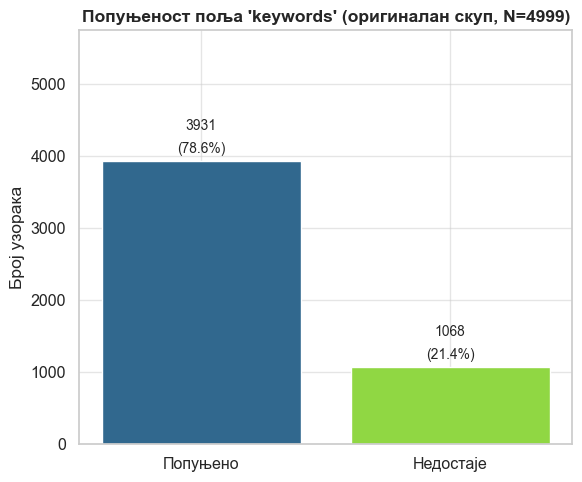

In [22]:
missing_kw = df_raw["keywords"].isna().sum()
total = len(df_raw)

fig, ax = plt.subplots(figsize=(6, 5))
vals = [total - missing_kw, missing_kw]
labs = ["Попуњено", "Недостаје"]
ax.bar(labs, vals, color=[sns.color_palette(PALETTE, 5)[1], sns.color_palette(PALETTE, 5)[4]])
for i, v in enumerate(vals):
    ax.text(i, v + total*0.015, f"{v}\n({v/total*100:.1f}%)",
             ha="center", va="bottom", fontsize=10, linespacing=1.8)
ax.set_ylabel("Број узорака")
ax.set_title("Попуњеност поља 'keywords' (оригиналан скуп, N=4999)", fontweight="bold")
ax.set_ylim(0, total * 1.15)
plt.tight_layout()
savefig(fig, "05_nedostajuci_keywords.png")
plt.show()

In [23]:
CUSTOM_STOPWORDS = set(ENGLISH_STOP_WORDS) | {
    "patient", "history", "procedure", "normal", "well", "postoperative",
    "preoperative", "time", "day", "diagnosis", "noted", "noted.", "given",
    "left", "right", "using", "use", "used", "performed", "without", "also",
    "presents", "presented", "consent", "discussed", "follow", "examination"
}

token_re = re.compile(r"[a-zA-Z]{3,}")

def clean_tokens(text):
    if not isinstance(text, str):
        return []
    tokens = token_re.findall(text.lower())
    return [t for t in tokens if t not in CUSTOM_STOPWORDS]

df["tokens"] = df["transcription"].apply(clean_tokens)
df["clean_text"] = df["tokens"].apply(lambda toks: " ".join(toks))
df["vocab_size"] = df["tokens"].apply(lambda toks: len(set(toks)))

print("Пример очишћеног текста (првих 200 карактера):")
print(df["clean_text"].iloc[0][:200])

Пример очишћеног текста (првих 200 карактера):
mode atrial enlargement atrial diameter size ventricle systolic function ventricular ejection fraction diastolic function pericardial effusion morphology aortic valve mitral valve tricuspid valve pulm


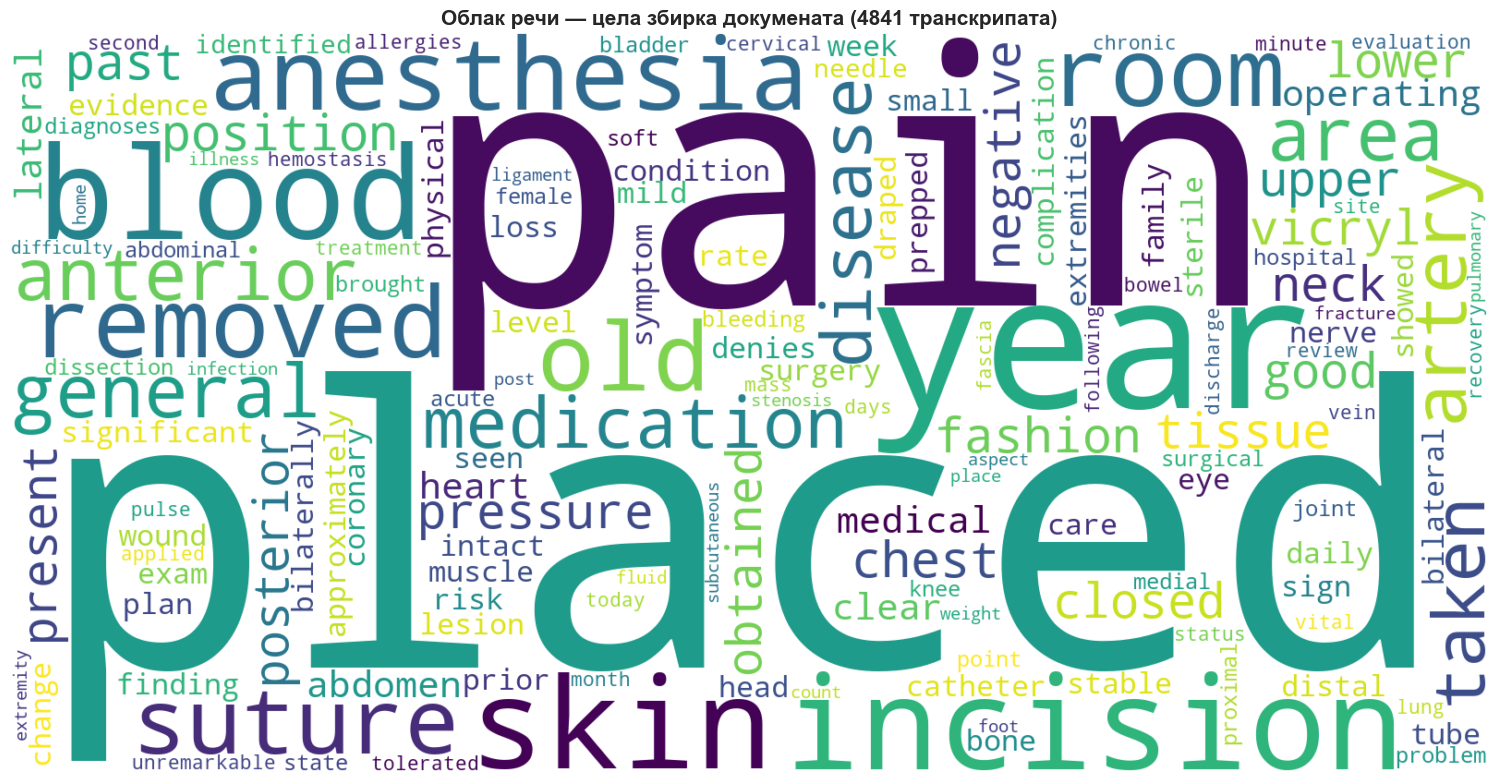

In [24]:
all_text = " ".join(df["clean_text"].tolist())

wc = WordCloud(width=1600, height=800, background_color="white",
               colormap=PALETTE, max_words=150, collocations=False,
               prefer_horizontal=0.95, random_state=42).generate(all_text)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Облак речи — цела збирка докумената (4841 транскрипата)", fontsize=15, fontweight="bold")
plt.tight_layout()
savefig(fig, "06_wordcloud_ceo.png")
plt.show()

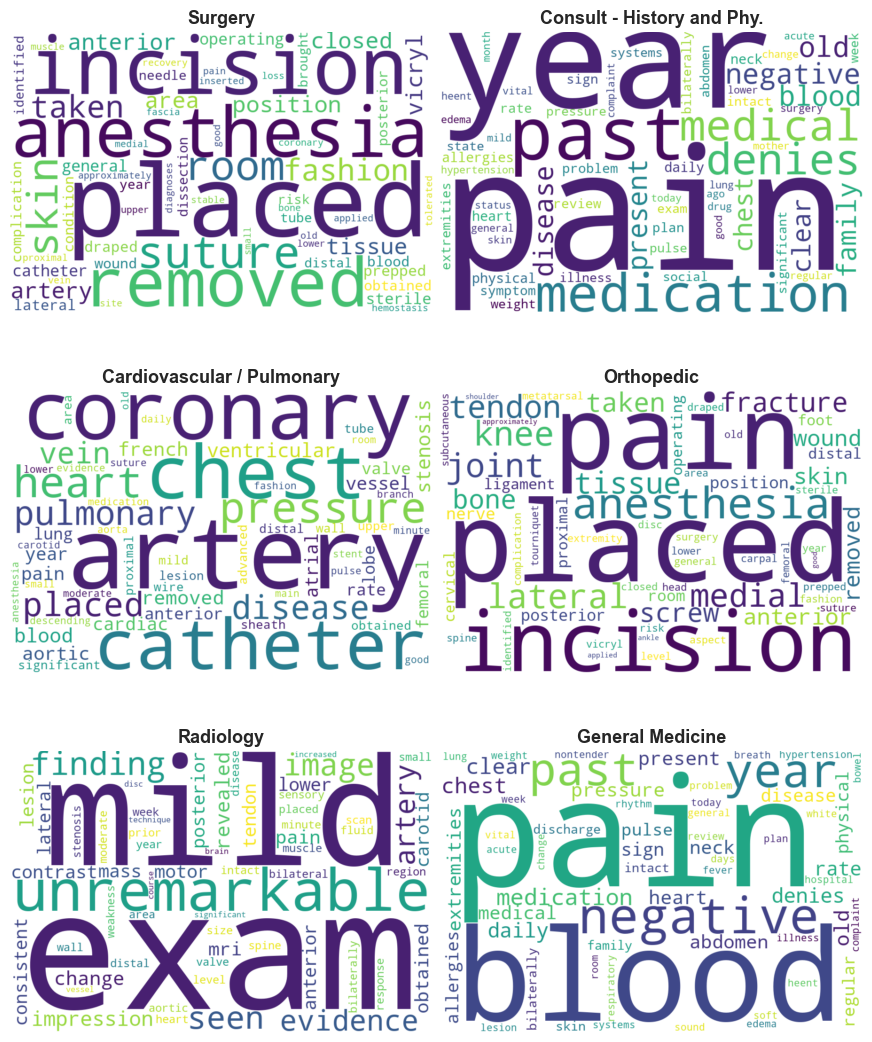

In [25]:
top6 = specialty_counts.sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(3, 2, figsize=(11, 13.5))
axes = axes.flatten()

for i, spec in enumerate(top6):
    text = " ".join(df.loc[df["medical_specialty"] == spec, "clean_text"].tolist())
    wc_spec = WordCloud(width=900, height=600, background_color="white",
                         colormap=PALETTE, max_words=60, collocations=False,
                         random_state=42).generate(text)
    axes[i].imshow(wc_spec, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(spec, fontsize=13, fontweight="bold")

plt.subplots_adjust(wspace=0.02, hspace=0.12)
savefig(fig, "07_wordcloud_po_specijalnosti.png")
plt.show()

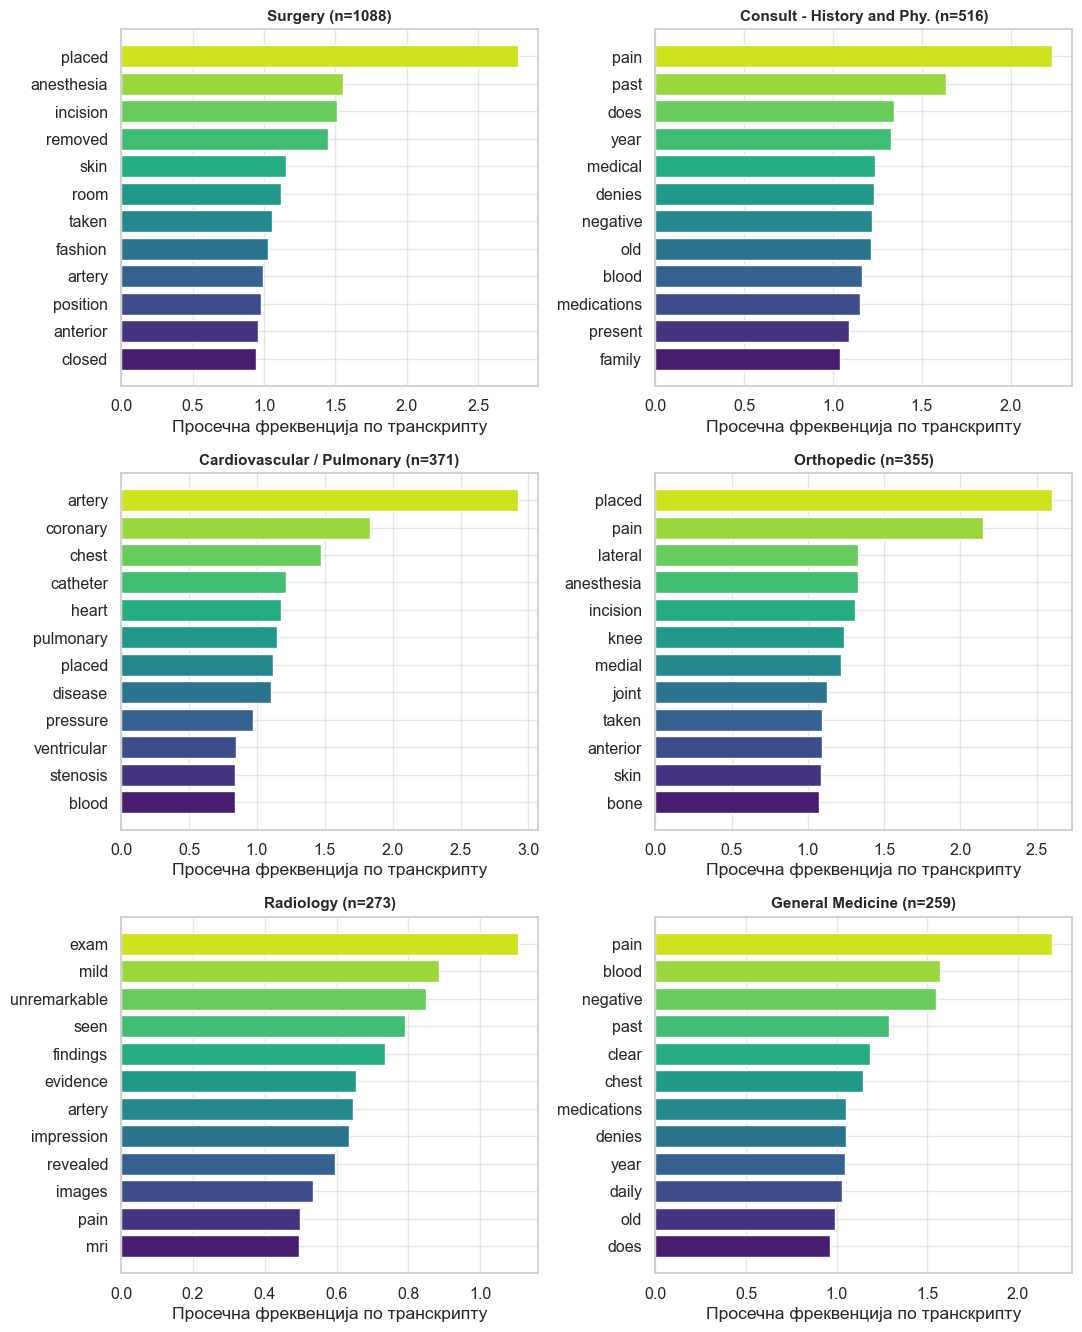

In [26]:
top6 = df["medical_specialty"].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(11, 13.5))
axes = axes.flatten()

for i, spec in enumerate(top6):
    sub = df.loc[df["medical_specialty"] == spec, "tokens"]
    n_docs = len(sub)

    toks = sum(sub.tolist(), [])
    common = Counter(toks).most_common(12)
    words, freqs = zip(*common[::-1])

    freqs_norm = [f / n_docs for f in freqs]

    axes[i].barh(words, freqs_norm, color=sns.color_palette(PALETTE, 12))
    axes[i].set_title(f"{spec} (n={n_docs})", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Просечна фреквенција по транскрипту")

plt.tight_layout()
savefig(fig, "08_top_termini_po_specijalnosti.png")
plt.show()

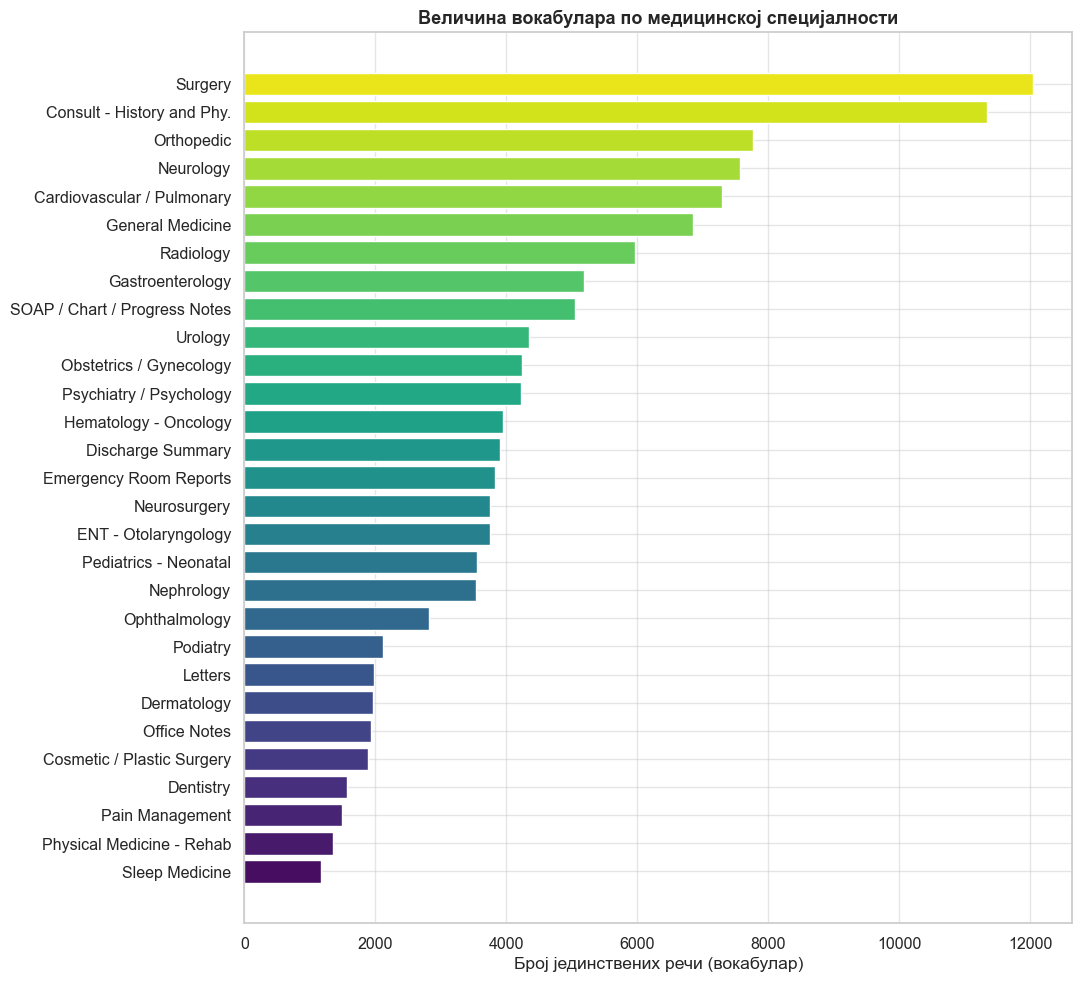

Корелација величине вокабулара и броја узорака по класи: r = 0.896


In [27]:
vocab_by_spec = df.groupby("medical_specialty")["tokens"].apply(lambda lists: len(set(sum(lists, [])))).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 10))
ax.barh(vocab_by_spec.index, vocab_by_spec.values, color=sns.color_palette(PALETTE, len(vocab_by_spec)))
ax.set_xlabel("Број јединствених речи (вокабулар)")
ax.set_title("Величина вокабулара по медицинској специјалности", fontsize=13, fontweight="bold")
plt.tight_layout()
savefig(fig, "09_vokabular_po_specijalnosti.png")
plt.show()

print("Корелација величине вокабулара и броја узорака по класи: r =",
      round(np.corrcoef(specialty_counts.reindex(vocab_by_spec.index), vocab_by_spec)[0,1], 3))

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams['font.family'] = 'Liberation Serif'

box_style = dict(boxstyle="round,pad=0.15", linewidth=1.3)

def draw_box(ax, x, y, w, h, title, subtitle, fontsize=12.5, sub_fontsize=9.3):
    box = FancyBboxPatch((x, y), w, h, **box_style,
                          facecolor="white", edgecolor='black', zorder=2)
    ax.add_patch(box)
    if subtitle:
        ax.text(x + w/2, y + h/2 + 0.18, title, ha='center', va='center',
                 fontsize=fontsize, fontweight='bold', color='black', zorder=3)
        ax.text(x + w/2, y + h/2 - 0.22, subtitle, ha='center', va='center',
                 fontsize=sub_fontsize, color='black', zorder=3, style='italic')
    else:
        ax.text(x + w/2, y + h/2, title, ha='center', va='center',
                 fontsize=fontsize, fontweight='bold', color='black', zorder=3)

def arrow(ax, x1, y1, x2, y2):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                         mutation_scale=15, linewidth=1.2, color='black', zorder=1)
    ax.add_patch(a)


fig, ax = plt.subplots(figsize=(15, 7))
ax.set_xlim(0, 15)
ax.set_ylim(0, 7)
ax.axis('off')

# Улазни текст (лево)
draw_box(ax, 0.3, 3.0, 1.8, 1.2, "Улазни текст", "транскрипт")

# Предобрада текста (заједничка за сва три модула)
draw_box(ax, 2.5, 3.0, 2.0, 1.2, "Предобрада текста", "чишћење, токенизација,\nлематизација", sub_fontsize=8.5)

# Три независна модула у средини
draw_box(ax, 5.3, 5.0, 2.8, 1.2, "Класификација", "TF-IDF+LinearSVC / SetFit")
draw_box(ax, 5.3, 2.9, 2.8, 1.2, "Семантичка претрага", "Sentence-Transformers + FAISS")
draw_box(ax, 5.3, 0.8, 2.8, 1.2, "Екстракција ентитета", "Ollama LLM + LLM-as-judge")

# Streamlit демо
draw_box(ax, 9.3, 2.9, 2.4, 1.2, "Streamlit демо", "кориснички интерфејс (UI)")

# Корisnik (десно)
draw_box(ax, 12.3, 2.9, 2.0, 1.2, "Корисник", "увид у резултате")

# Стрелица: улаз -> предобрада
arrow(ax, 2.15, 3.6, 2.45, 3.6)

# Стрелице: предобрада -> три модула
arrow(ax, 4.55, 3.85, 5.2, 5.35)
arrow(ax, 4.55, 3.6, 5.2, 3.5)
arrow(ax, 4.55, 3.25, 5.2, 1.65)

# Стрелице: три модула -> Streamlit демо
arrow(ax, 8.2, 5.3, 9.2, 3.95)
arrow(ax, 8.2, 3.5, 9.2, 3.5)
arrow(ax, 8.2, 1.7, 9.2, 3.05)

# Streamlit демо -> Корисник
arrow(ax, 11.8, 3.5, 12.2, 3.5)

ax.text(7.5, 6.6, "Архитектура система", ha='center', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('arhitektura_sistema_v2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("сачувано")

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

сачувано


In [32]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams['font.family'] = 'Liberation Serif'

box_style = dict(boxstyle="round,pad=0.15", linewidth=1.3)

def draw_box(ax, x, y, w, h, title, subtitle, fontsize=12.5, sub_fontsize=9.3):
    box = FancyBboxPatch((x, y), w, h, **box_style,
                          facecolor="white", edgecolor='black', zorder=2)
    ax.add_patch(box)
    if subtitle:
        ax.text(x + w/2, y + h/2 + 0.18, title, ha='center', va='center',
                 fontsize=fontsize, fontweight='bold', color='black', zorder=3)
        ax.text(x + w/2, y + h/2 - 0.22, subtitle, ha='center', va='center',
                 fontsize=sub_fontsize, color='black', zorder=3, style='italic')
    else:
        ax.text(x + w/2, y + h/2, title, ha='center', va='center',
                 fontsize=fontsize, fontweight='bold', color='black', zorder=3)

def arrow(ax, x1, y1, x2, y2):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                         mutation_scale=15, linewidth=1.2, color='black', zorder=1)
    ax.add_patch(a)


# ============================================================
# 4.1 Tok obrade klasifikacije
# ============================================================
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4.5)
ax.axis('off')

draw_box(ax, 0.2, 1.6, 1.7, 1.0, "Улазни текст", "транскрипт")
draw_box(ax, 2.4, 1.6, 2.1, 1.0, "Предобрада текста", "чишћење, токенизација,\nлематизација", fontsize=11, sub_fontsize=8)
draw_box(ax, 5.1, 2.6, 2.2, 1.0, "TF-IDF + LinearSVC", "GridSearchCV")
draw_box(ax, 5.1, 0.6, 2.2, 1.0, "SetFit", "few-shot учење")
draw_box(ax, 8.4, 1.6, 2.3, 1.0, "Предикција класе", "29 специјалности")
draw_box(ax, 11.4, 1.6, 1.4, 1.0, "Резултат", "", fontsize=11.5)

arrow(ax, 1.95, 2.1, 2.35, 2.1)
arrow(ax, 4.55, 2.35, 5.15, 3.05)
arrow(ax, 4.55, 1.85, 5.15, 1.15)
arrow(ax, 7.35, 3.05, 8.45, 2.3)
arrow(ax, 7.35, 1.15, 8.45, 1.9)
arrow(ax, 10.75, 2.1, 11.35, 2.1)

ax.text(6.5, 4.2, "Ток обраде класификације", ha='center', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('pipeline_klasifikacija_4_1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()


# ============================================================
# 4.2 Semantička pretraga
# ============================================================
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.2)
ax.axis('off')

draw_box(ax, 0.2, 1.1, 1.9, 1.0, "Генерисање embedding-а", "Sentence-Transformers", fontsize=11)
draw_box(ax, 3.0, 1.1, 1.9, 1.0, "FAISS индексирање", "векторска база")
draw_box(ax, 5.8, 1.1, 1.7, 1.0, "Упит (query)", "корисников текст")
draw_box(ax, 8.4, 1.1, 2.2, 1.0, "Топ-к резултати", "слични транскрипти")

arrow(ax, 2.15, 1.6, 2.95, 1.6)
arrow(ax, 4.95, 1.6, 5.75, 1.6)
arrow(ax, 7.55, 1.6, 8.35, 1.6)

ax.text(5.5, 2.9, "Pipeline семантичке претраге", ha='center', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('pipeline_pretraga_4_2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()


# ============================================================
# 4.3 Ekstrakcija entiteta
# ============================================================
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.2)
ax.axis('off')

draw_box(ax, 0.2, 1.1, 1.5, 1.0, "Текст", "транскрипт")
draw_box(ax, 2.3, 1.1, 1.9, 1.0, "LLM позив", "Ollama (локални модел)")
draw_box(ax, 4.8, 1.1, 2.0, 1.0, "Structured JSON", "ентитети")
draw_box(ax, 7.4, 1.1, 2.5, 1.0, "LLM-as-judge провера", "Groq хетероген панел")

arrow(ax, 1.75, 1.6, 2.25, 1.6)
arrow(ax, 4.25, 1.6, 4.75, 1.6)
arrow(ax, 6.85, 1.6, 7.35, 1.6)

ax.text(5.5, 2.9, "Pipeline екстракције ентитета", ha='center', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('pipeline_ekstrakcija_4_3.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()

print("Сви дијаграми сачувани")

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

Сви дијаграми сачувани


сачувано


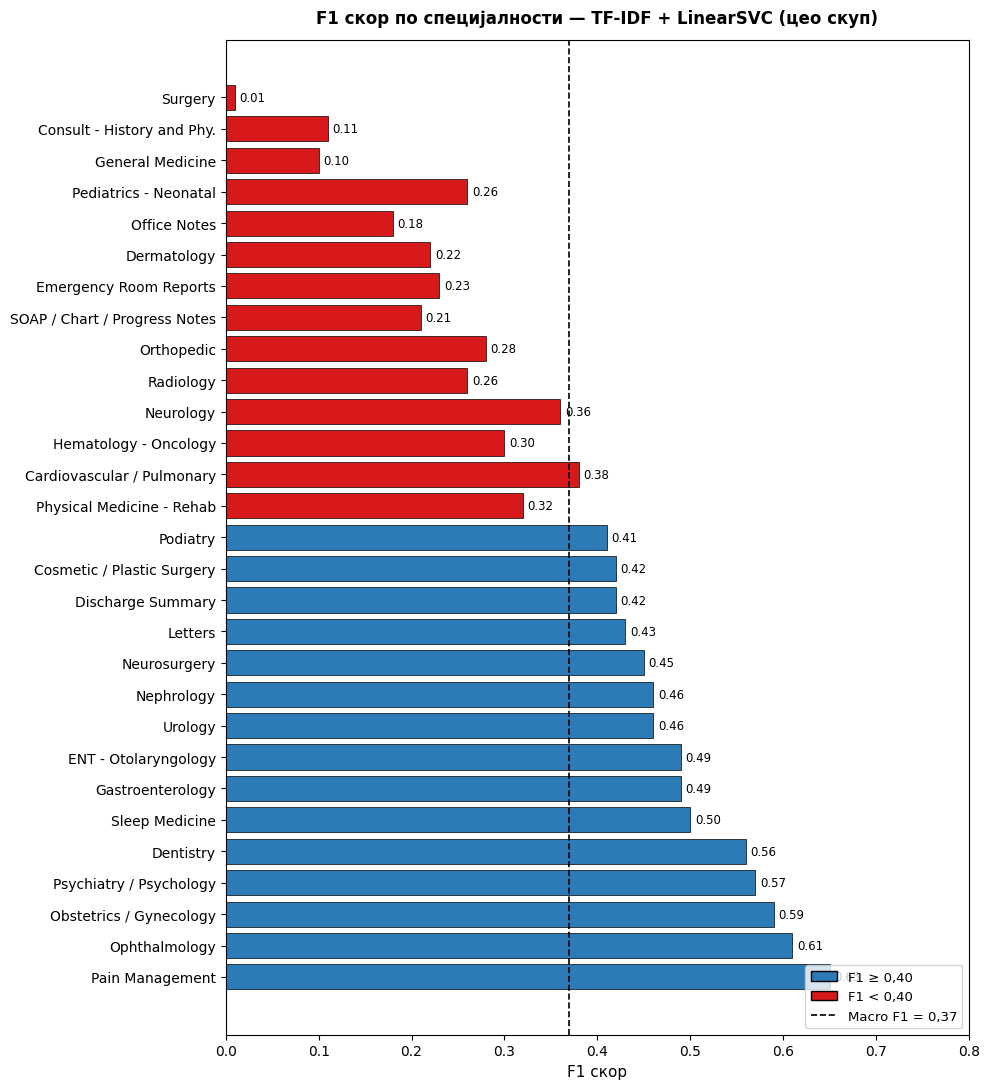

In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Liberation Serif'
plt.style.use('default')

classes = [
    'Pain Management', 'Ophthalmology', 'Obstetrics / Gynecology',
    'Psychiatry / Psychology', 'Dentistry', 'Sleep Medicine',
    'Gastroenterology', 'ENT - Otolaryngology', 'Urology',
    'Nephrology', 'Neurosurgery', 'Letters', 'Discharge Summary',
    'Cosmetic / Plastic Surgery', 'Podiatry', 'Physical Medicine - Rehab',
    'Cardiovascular / Pulmonary', 'Hematology - Oncology',
    'Neurology', 'Radiology', 'Orthopedic', 'SOAP / Chart / Progress Notes',
    'Emergency Room Reports', 'Dermatology', 'Office Notes',
    'Pediatrics - Neonatal', 'General Medicine',
    'Consult - History and Phy.', 'Surgery'
]

f1_scores = [
    0.65, 0.61, 0.59, 0.57, 0.56, 0.50,
    0.49, 0.49, 0.46, 0.46, 0.45, 0.43,
    0.42, 0.42, 0.41, 0.32, 0.38, 0.30,
    0.36, 0.26, 0.28, 0.21, 0.23, 0.22,
    0.18, 0.26, 0.10, 0.11, 0.01
]

colors = ['#2c7bb6' if f >= 0.40 else '#d7191c' for f in f1_scores]

fig, ax = plt.subplots(figsize=(10, 11))
bars = ax.barh(classes, f1_scores, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, f1_scores):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8.5)

ax.set_xlabel('F1 скор', fontsize=11)
ax.set_xlim(0, 0.80)
ax.axvline(x=0.37, color='black', linestyle='--', linewidth=1.2,
           label=f'Macro F1 = 0,37')
ax.legend(fontsize=9.5)
ax.set_title('F1 скор по специјалности — TF-IDF + LinearSVC (цео скуп)',
             fontsize=12, fontweight='bold', pad=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2c7bb6', edgecolor='black', label='F1 ≥ 0,40'),
    Patch(facecolor='#d7191c', edgecolor='black', label='F1 < 0,40'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1.2,
               label='Macro F1 = 0,37')
], fontsize=9.5, loc='lower right')

plt.tight_layout()
plt.savefig('f1_po_klasi_tfidf_ceo_skup.png', dpi=300, bbox_inches='tight', facecolor='white')
print("сачувано")

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

сачувано


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.


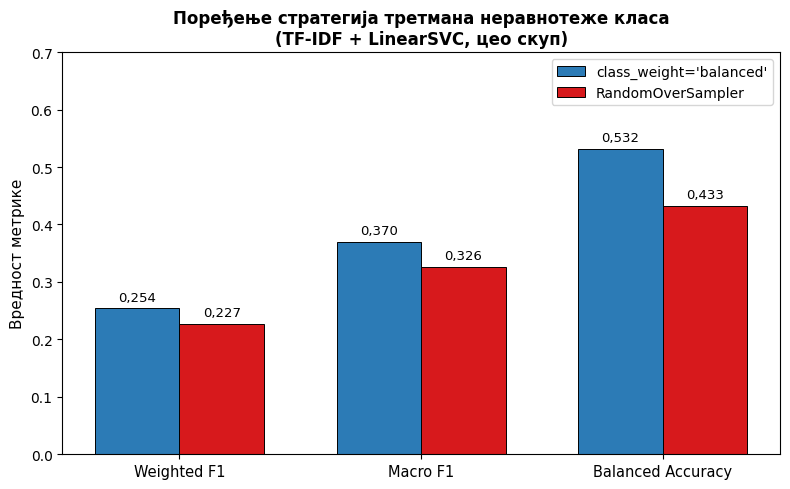

In [6]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')
import matplotlib
matplotlib.rcParams['font.family'] = 'Liberation Serif'

metrics = ['Weighted F1', 'Macro F1', 'Balanced Accuracy']
balanced = [0.254, 0.370, 0.532]
ros = [0.227, 0.326, 0.433]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

bars1 = ax.bar(x - width/2, balanced, width, label="class_weight='balanced'",
               color='#2c7bb6', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, ros, width, label='RandomOverSampler',
               color='#d7191c', edgecolor='black', linewidth=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}'.replace('.', ','),
            ha='center', va='bottom', fontsize=9.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}'.replace('.', ','),
            ha='center', va='bottom', fontsize=9.5)

ax.set_ylabel('Вредност метрике', fontsize=11)
ax.set_ylim(0, 0.70)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10.5)
ax.legend(fontsize=10)
ax.set_title('Поређење стратегија третмана неравнотеже класа\n(TF-IDF + LinearSVC, цео скуп)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('balansiranje_poredjenje.png', dpi=300, bbox_inches='tight', facecolor='white')
print("сачувано")

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

сачувано


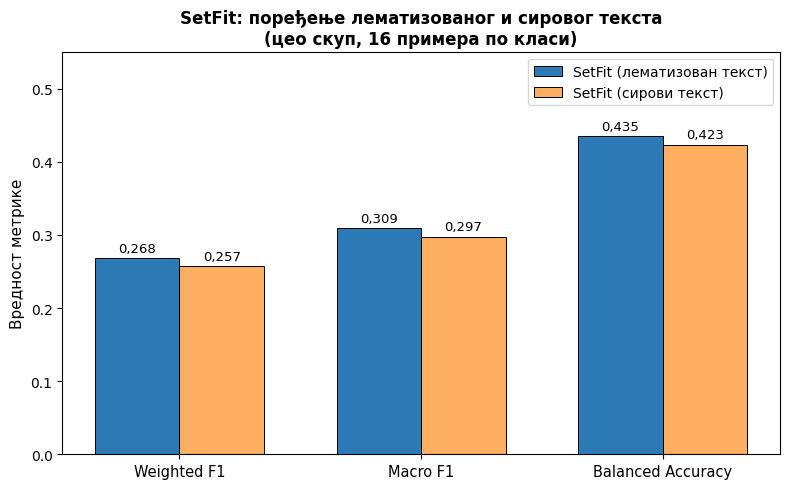

In [8]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')
import matplotlib
matplotlib.rcParams['font.family'] = 'Liberation Serif'

metrics = ['Weighted F1', 'Macro F1', 'Balanced Accuracy']
lemmatized = [0.268, 0.309, 0.435]
raw = [0.257, 0.297, 0.423]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

bars1 = ax.bar(x - width/2, lemmatized, width, label='SetFit (лематизован текст)',
               color='#2c7bb6', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, raw, width, label='SetFit (сирови текст)',
               color='#fdae61', edgecolor='black', linewidth=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}'.replace('.', ','),
            ha='center', va='bottom', fontsize=9.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}'.replace('.', ','),
            ha='center', va='bottom', fontsize=9.5)

ax.set_ylabel('Вредност метрике', fontsize=11)
ax.set_ylim(0, 0.55)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10.5)
ax.legend(fontsize=10)
ax.set_title('SetFit: поређење лематизованог и сировог текста\n(цео скуп, 16 примера по класи)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('setfit_lemma_vs_raw.png', dpi=300, bbox_inches='tight', facecolor='white')
print("сачувано")

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

сачувано


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

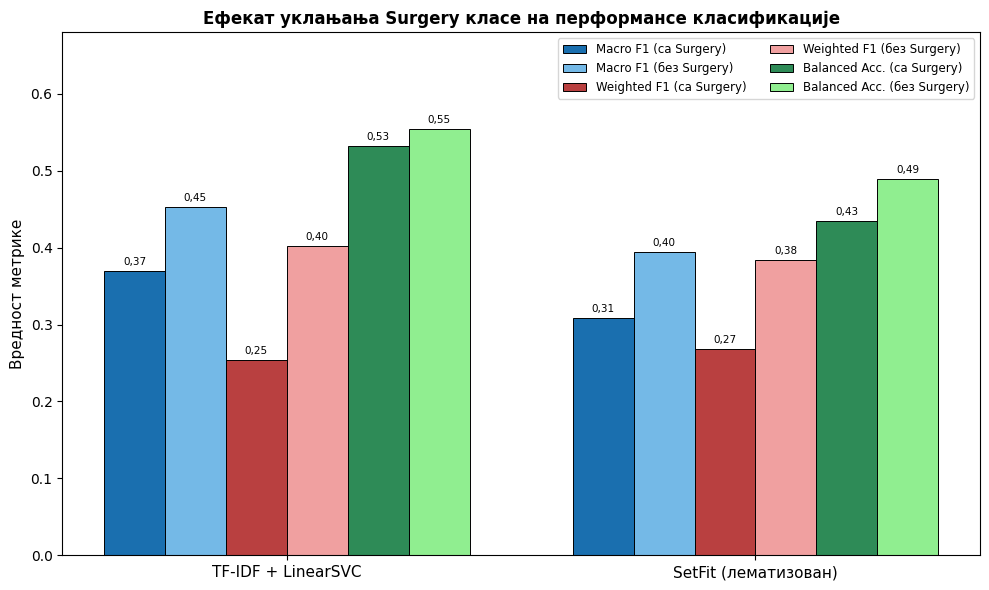

In [11]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')
import matplotlib
matplotlib.rcParams['font.family'] = 'Liberation Serif'

models = ['TF-IDF + LinearSVC', 'SetFit (лематизован)']
macro_with = [0.370, 0.309]
macro_without = [0.453, 0.395]
weighted_with = [0.254, 0.268]
weighted_without = [0.402, 0.384]
bacc_with = [0.532, 0.435]
bacc_without = [0.554, 0.489]

x = np.arange(len(models))
width = 0.13

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

b1 = ax.bar(x - 2.5*width, macro_with,    width, label='Macro F1 (са Surgery)',       color='#1a6faf', edgecolor='black', linewidth=0.7)
b2 = ax.bar(x - 1.5*width, macro_without, width, label='Macro F1 (без Surgery)',      color='#74b9e7', edgecolor='black', linewidth=0.7)
b3 = ax.bar(x - 0.5*width, weighted_with,    width, label='Weighted F1 (са Surgery)', color='#b94040', edgecolor='black', linewidth=0.7)
b4 = ax.bar(x + 0.5*width, weighted_without, width, label='Weighted F1 (без Surgery)',color='#f0a0a0', edgecolor='black', linewidth=0.7)
b5 = ax.bar(x + 1.5*width, bacc_with,    width, label='Balanced Acc. (са Surgery)',   color='#2e8b57', edgecolor='black', linewidth=0.7)
b6 = ax.bar(x + 2.5*width, bacc_without, width, label='Balanced Acc. (без Surgery)', color='#90ee90', edgecolor='black', linewidth=0.7)

for bars in [b1, b2, b3, b4, b5, b6]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}'.replace('.', ','),
                ha='center', va='bottom', fontsize=7.5)

ax.set_ylabel('Вредност метрике', fontsize=11)
ax.set_ylim(0, 0.68)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=8.5, loc='upper right', ncol=2)
ax.set_title('Ефекат уклањања Surgery класе на перформансе класификације',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('surgery_removal_before_after.png', dpi=300, bbox_inches='tight', facecolor='white')
print("сачувано")

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

сачувано


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

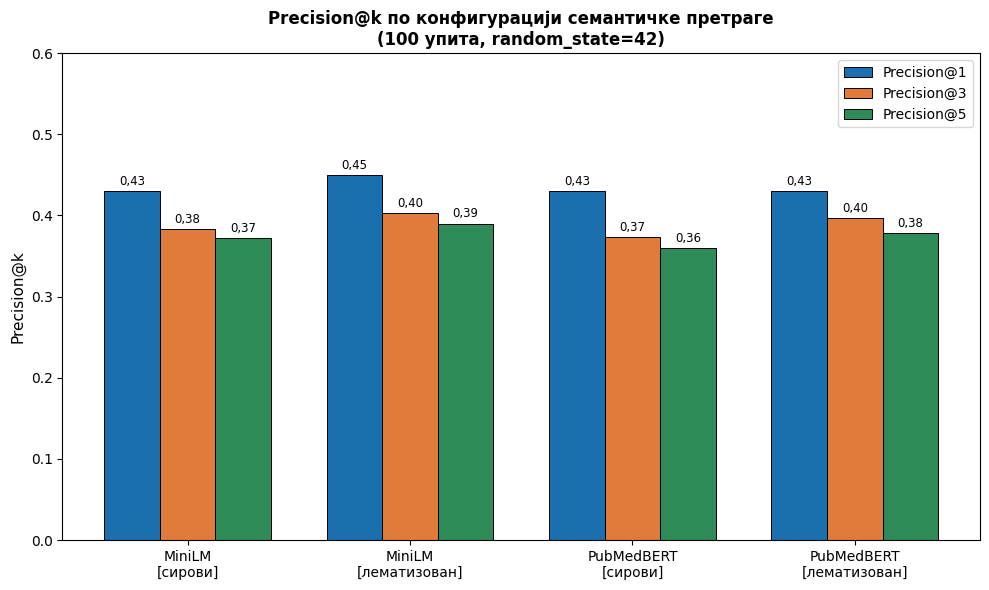

In [12]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')
import matplotlib
matplotlib.rcParams['font.family'] = 'Liberation Serif'

configs = [
    'MiniLM\n[сирови]',
    'MiniLM\n[лематизован]',
    'PubMedBERT\n[сирови]',
    'PubMedBERT\n[лематизован]'
]

p1 = [0.43, 0.45, 0.43, 0.43]
p3 = [0.383, 0.403, 0.373, 0.397]
p5 = [0.372, 0.390, 0.360, 0.378]

x = np.arange(len(configs))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

b1 = ax.bar(x - width, p1, width, label='Precision@1', color='#1a6faf', edgecolor='black', linewidth=0.7)
b2 = ax.bar(x,         p3, width, label='Precision@3', color='#e07b39', edgecolor='black', linewidth=0.7)
b3 = ax.bar(x + width, p5, width, label='Precision@5', color='#2e8b57', edgecolor='black', linewidth=0.7)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.2f}'.replace('.', ','),
                ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('Precision@k', fontsize=11)
ax.set_ylim(0, 0.60)
ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=10)
ax.legend(fontsize=10)
ax.set_title('Precision@k по конфигурацији семантичке претраге\n(100 упита, random_state=42)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('semantic_search_precision_k.png', dpi=300, bbox_inches='tight', facecolor='white')
print("сачувано")

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

сачувано


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.


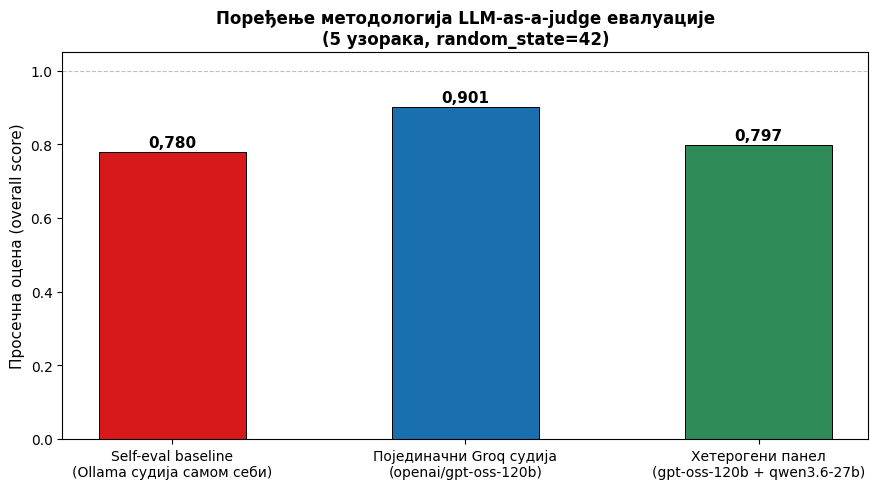

In [13]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')
import matplotlib
matplotlib.rcParams['font.family'] = 'Liberation Serif'

methods = ['Self-eval baseline\n(Ollama судија самом себи)', 'Појединачни Groq судија\n(openai/gpt-oss-120b)', 'Хетерогени панел\n(gpt-oss-120b + qwen3.6-27b)']
scores = [0.780, 0.901, 0.797]
colors = ['#d7191c', '#1a6faf', '#2e8b57']

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.set_facecolor('white')

bars = ax.bar(methods, scores, color=colors, edgecolor='black', linewidth=0.7, width=0.5)

for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}'.replace('.', ','),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Просечна оцена (overall score)', fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Поређење методологија LLM-as-a-judge евалуације\n(5 узорака, random_state=42)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('judge_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print("сачувано")